In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
from config import TRAIN_FILE

train_df = pd.read_csv(str(TRAIN_FILE), encoding="utf-8-sig")
train_texts = train_df["processed_text"].fillna("").astype(str)

print(f"训练集: {len(train_df)} 条")
print(f"示例:")
for i in range(3):
    print(f"  [{train_df.iloc[i]['category']}] {train_texts.iloc[i][:80]}...")

训练集: 6181 条
示例:
  [nan] 吊丝 出发 跑步 燃烧 脂肪 鸟...
  [nan] 风哥 风兄 敦儿哥 za 儿哥 生快 听说 有大 蛋糕...
  [nan] 一记 耳光 打 够 响亮 不知 是否 能 打醒 未知数...


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from config import TFIDF_MAX_FEATURES, TFIDF_MAX_DF, TFIDF_MIN_DF, TFIDF_NGRAM_RANGE

vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,  # 词表上限 5000
    max_df=TFIDF_MAX_DF,              # 出现在 85%+ 文档中的词忽略
    min_df=TFIDF_MIN_DF,              # 只出现在 1 篇中的词忽略
    ngram_range=TFIDF_NGRAM_RANGE,    # unigram + bigram
    sublinear_tf=True,                # TF 取对数: 1 + log(f)
)

print("TfidfVectorizer 参数:")
print(f"  max_features = {TFIDF_MAX_FEATURES}")
print(f"  max_df       = {TFIDF_MAX_DF}")
print(f"  min_df       = {TFIDF_MIN_DF}")
print(f"  ngram_range  = {TFIDF_NGRAM_RANGE}")
print(f"  sublinear_tf = True")
print(f"  norm         = l2 (默认)")

TfidfVectorizer 参数:
  max_features = 5000
  max_df       = 0.85
  min_df       = 2
  ngram_range  = (1, 2)
  sublinear_tf = True
  norm         = l2 (默认)


In [3]:
import numpy as np

tfidf_matrix = vectorizer.fit_transform(train_texts)
feature_names = vectorizer.get_feature_names_out()

print(f"文档-词项矩阵形状: {tfidf_matrix.shape}")
print(f"  N (文档数):   {tfidf_matrix.shape[0]}")
print(f"  V (词表大小): {tfidf_matrix.shape[1]}")
print(f"  非零元素数:   {tfidf_matrix.nnz}")
print(f"  稀疏度:       {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")
print(f"\n词表前 20 个词: {list(feature_names[:20])}")
print(f"词表后 20 个词: {list(feature_names[-20:])}")

文档-词项矩阵形状: (6181, 5000)
  N (文档数):   6181
  V (词表大小): 5000
  非零元素数:   47137
  稀疏度:       99.85%

词表前 20 个词: ['00', '01', '03', '04', '10', '10 分钟', '100', '1000', '10000', '11', '110', '12', '128', '128m', '13', '14', '15', '150', '16', '160g']
词表后 20 个词: ['高速', '高铁', '高频', '魅力', '魔兽', '魔兽 世界', '魔力', '魔法', '鸡蛋', '麻烦', '麻麻', '黄色', '黑屏', '黑白', '黑色', '默认', '鼓励', '鼓浪屿', '鼠标', '龙虾']


热力图已保存: D:\code-hub\ml-service\outputs\figures\tfidf_heatmap.png


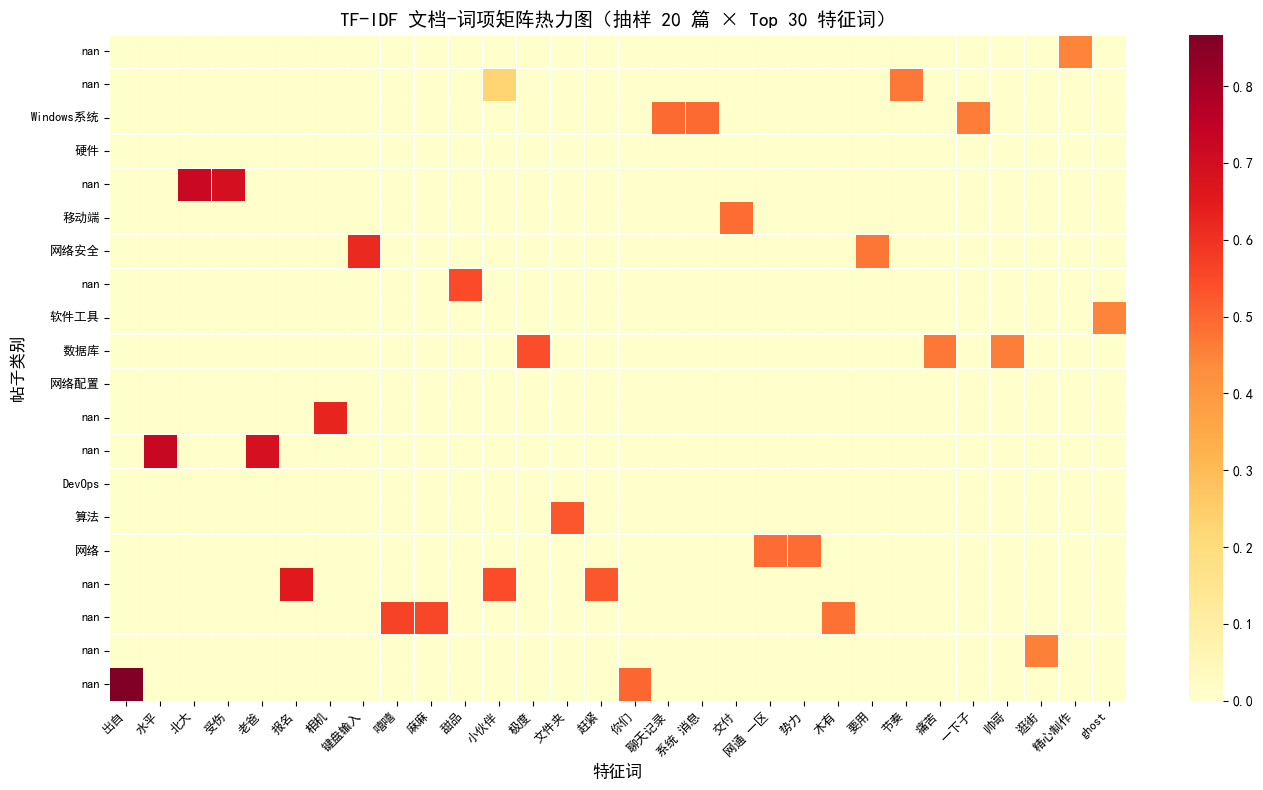

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from config import FIGURES_DIR

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "WenQuanYi Micro Hei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

# 随机抽 20 篇帖子，取 top 30 高频特征词
np.random.seed(42)
sample_idx = np.random.choice(tfidf_matrix.shape[0], size=min(20, tfidf_matrix.shape[0]), replace=False)
sample_matrix = tfidf_matrix[sample_idx].toarray()

# 找出这 20 篇中权重最高的 30 个特征
col_max = sample_matrix.max(axis=0)
top_feature_idx = col_max.argsort()[-30:][::-1]
top_feature_names = [feature_names[i] for i in top_feature_idx]

heatmap_data = sample_matrix[:, top_feature_idx]

# 行标签用 category
row_labels = [f"{train_df.iloc[i]['category']}" for i in sample_idx]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    xticklabels=top_feature_names,
    yticklabels=row_labels,
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("TF-IDF 文档-词项矩阵热力图（抽样 20 篇 × Top 30 特征词）", fontsize=14)
ax.set_xlabel("特征词", fontsize=12)
ax.set_ylabel("帖子类别", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

os.makedirs(str(FIGURES_DIR), exist_ok=True)
fig.savefig(str(FIGURES_DIR / "tfidf_heatmap.png"), dpi=200)
print(f"热力图已保存: {FIGURES_DIR / 'tfidf_heatmap.png'}")
plt.show()

In [5]:
import joblib
from config import TFIDF_MODEL_FILE, MODELS_DIR

os.makedirs(str(MODELS_DIR), exist_ok=True)
joblib.dump(vectorizer, str(TFIDF_MODEL_FILE))

# 验证：重新加载并检查
loaded = joblib.load(str(TFIDF_MODEL_FILE))
test_vec = loaded.transform(["React hooks 状态管理 组件"])
print(f"模型已保存: {TFIDF_MODEL_FILE}")
print(f"文件大小: {os.path.getsize(str(TFIDF_MODEL_FILE)) / 1024:.1f} KB")
print(f"验证 transform: shape={test_vec.shape}, nnz={test_vec.nnz}")

模型已保存: D:\code-hub\ml-service\models\tfidf_vectorizer.pkl
文件大小: 1444.7 KB
验证 transform: shape=(1, 5000), nnz=2
